# 04 — Optimisation

## Objectif
1. Optimiser les hyperparamètres du meilleur modèle (LightGBM) avec **Optuna**
2. Optimiser le **seuil de décision** pour minimiser le coût métier
3. Tracer la courbe **coût vs seuil**

## Rappel coût métier
- FN (mauvais client prédit bon) → perte en capital → coût = **10**
- FP (bon client prédit mauvais) → manque à gagner → coût = **1**
- `coût_métier = 10 × FN + 1 × FP`

## Pourquoi LightGBM ?
D'après les baselines du notebook 03 :
- Meilleur F1 (0.2866) et coût métier compétitif (1210) parmi les tree-based
- CV AUC stable (0.7004 ± 0.0183)
- Plus rapide à entraîner que XGBoost

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import optuna
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report
from lightgbm import LGBMClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)  # moins de logs Optuna
print('Imports OK')

Imports OK


## 1. Chargement des données

In [11]:
df = pd.read_csv('../data/train_preprocessed.csv')
y = df['TARGET']
X = df.drop(columns=['TARGET'])
X.columns = X.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Ratio négatifs/positifs : {neg/pos:.2f}')

Train : (246008, 244)  |  Test : (61503, 244)
Ratio négatifs/positifs : 11.39


## 2. Optimisation des hyperparamètres avec Optuna

**Optuna** teste automatiquement des combinaisons d'hyperparamètres et cherche
celles qui maximisent (ou minimisent) une métrique donnée.

Contrairement à `GridSearchCV` qui teste **toutes** les combinaisons d'une grille,
Optuna utilise un algorithme bayésien (TPE) qui **apprend** des essais précédents
pour proposer des combinaisons plus prometteuses → plus efficace.

On optimise ici la **CV AUC** (StratifiedKFold 5 folds) pour trouver
les meilleurs hyperparamètres LightGBM.

In [12]:
def objective(trial):
    """Fonction objectif pour Optuna : retourne la CV AUC à maximiser."""
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 15, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': neg / pos,
        'random_state':     42,
        'verbose':          -1,
        'n_jobs':           -1,
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr  = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr  = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = LGBMClassifier(**params)
        model.fit(X_tr, y_tr)
        y_proba = model.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, y_proba))

    return np.mean(aucs)

print('Fonction objective définie')

Fonction objective définie


In [13]:
# Lancer l'optimisation : 50 essais
study = optuna.create_study(direction='maximize')  # maximiser AUC
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nMeilleure CV AUC : {study.best_value:.4f}')
print(f'Meilleurs hyperparamètres :')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Best trial: 42. Best value: 0.773116: 100%|██████████| 50/50 [47:26<00:00, 56.93s/it]


Meilleure CV AUC : 0.7731
Meilleurs hyperparamètres :
  n_estimators: 452
  max_depth: 10
  learning_rate: 0.03334789959637915
  num_leaves: 41
  min_child_samples: 38
  subsample: 0.8445691726741573
  colsample_bytree: 0.6409016614512465
  reg_alpha: 6.46378438464145
  reg_lambda: 0.0703691194715655


## 3. Entraînement du modèle optimisé

On entraîne un LightGBM final avec les meilleurs hyperparamètres trouvés par Optuna,
puis on évalue sur le holdout set.

In [14]:
# Construire les paramètres finaux
best_params = study.best_params.copy()
best_params['scale_pos_weight'] = neg / pos
best_params['random_state'] = 42
best_params['verbose'] = -1
best_params['n_jobs'] = -1

# Entraîner sur tout X_train
lgbm_optimized = LGBMClassifier(**best_params)
lgbm_optimized.fit(X_train, y_train)

# Probabilités sur le holdout
y_proba = lgbm_optimized.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f'Holdout AUC (seuil par défaut 0.5) : {auc:.4f}')

Holdout AUC (seuil par défaut 0.5) : 0.7781


## 4. Optimisation du seuil de décision

Par défaut, un modèle utilise le seuil **0.5** : si `P(TARGET=1) >= 0.5`, on prédit 1.

Mais notre coût métier est **asymétrique** (FN coûte 10× plus que FP).
En **baissant le seuil**, on devient plus prudent :
- Plus de clients classés "mauvais" → moins de FN
- Mais plus de FP (bons clients refusés)

On teste tous les seuils de **0.1 à 0.9** et on trace la courbe coût vs seuil
pour trouver le seuil optimal.

In [15]:
# Tester les seuils de 0.05 à 0.95 par pas de 0.01
seuils = np.arange(0.05, 0.96, 0.01)
results = []

for s in seuils:
    y_pred = (y_proba >= s).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    cout = 10 * fn + 1 * fp
    f1 = f1_score(y_test, y_pred, zero_division=0)
    results.append({'seuil': s, 'cout_metier': cout, 'fn': fn, 'fp': fp, 'f1': f1})

df_seuils = pd.DataFrame(results)

# Trouver le seuil optimal
idx_best = df_seuils['cout_metier'].idxmin()
best_seuil = df_seuils.loc[idx_best, 'seuil']
best_cout  = df_seuils.loc[idx_best, 'cout_metier']
best_fn    = df_seuils.loc[idx_best, 'fn']
best_fp    = df_seuils.loc[idx_best, 'fp']
best_f1    = df_seuils.loc[idx_best, 'f1']

print(f'Seuil optimal    : {best_seuil:.2f}')
print(f'Coût métier min  : {best_cout:.0f}  (FN={best_fn:.0f}, FP={best_fp:.0f})')
print(f'F1 au seuil opt  : {best_f1:.4f}')

Seuil optimal    : 0.51
Coût métier min  : 30816  (FN=1658, FP=14236)
F1 au seuil opt  : 0.2939


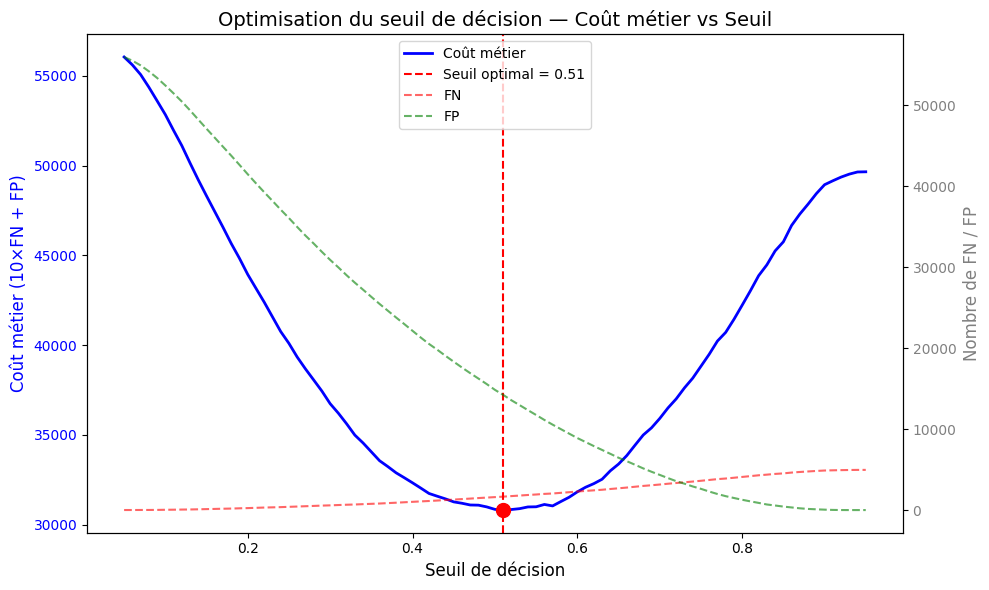


→ Le seuil 0.51 minimise le coût métier à 30816
  Comparaison avec seuil 0.5 : coût = 30855


In [16]:
# Courbe coût métier vs seuil
fig, ax1 = plt.subplots(figsize=(10, 6))

# Axe principal : coût métier
ax1.plot(df_seuils['seuil'], df_seuils['cout_metier'], 'b-', linewidth=2, label='Coût métier')
ax1.axvline(x=best_seuil, color='red', linestyle='--', linewidth=1.5, label=f'Seuil optimal = {best_seuil:.2f}')
ax1.scatter([best_seuil], [best_cout], color='red', s=100, zorder=5)
ax1.set_xlabel('Seuil de décision', fontsize=12)
ax1.set_ylabel('Coût métier (10×FN + FP)', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Axe secondaire : FN et FP
ax2 = ax1.twinx()
ax2.plot(df_seuils['seuil'], df_seuils['fn'], 'r--', alpha=0.6, label='FN')
ax2.plot(df_seuils['seuil'], df_seuils['fp'], 'g--', alpha=0.6, label='FP')
ax2.set_ylabel('Nombre de FN / FP', fontsize=12, color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', fontsize=10)

plt.title('Optimisation du seuil de décision — Coût métier vs Seuil', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\n→ Le seuil {best_seuil:.2f} minimise le coût métier à {best_cout:.0f}')
print(f'  Comparaison avec seuil 0.5 : coût = {df_seuils[df_seuils["seuil"].round(2) == 0.50]["cout_metier"].values[0]:.0f}')

## 5. Résultats finaux + Log MLflow

On logge le modèle optimisé (hyperparamètres Optuna + seuil optimal) dans MLflow.

In [17]:
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('scoring_credit')

# Prédictions finales avec le seuil optimal
y_pred_final = (y_proba >= best_seuil).astype(int)
auc_final = roc_auc_score(y_test, y_proba)
f1_final  = f1_score(y_test, y_pred_final)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
cout_final = 10 * fn + 1 * fp

with mlflow.start_run(run_name='LightGBM_optimized'):

    mlflow.set_tag('model', 'LightGBM')
    mlflow.set_tag('stage', 'optimized')

    # Hyperparamètres
    mlflow.log_params(best_params)
    mlflow.log_param('seuil_optimal', best_seuil)

    # Métriques
    mlflow.log_metric('optuna_best_cv_auc', study.best_value)
    mlflow.log_metric('test_auc', auc_final)
    mlflow.log_metric('f1', f1_final)
    mlflow.log_metric('cout_metier', cout_final)
    mlflow.log_metric('fn', fn)
    mlflow.log_metric('fp', fp)
    mlflow.log_metric('seuil_optimal', best_seuil)

    # Modèle
    mlflow.sklearn.log_model(
        lgbm_optimized, name='model',
        registered_model_name='ScoringCredit_LightGBM_Optimized'
    )

print('=== RÉSULTATS FINAUX — LightGBM Optimisé ===')
print(f'Optuna CV AUC      : {study.best_value:.4f}')
print(f'Holdout AUC        : {auc_final:.4f}')
print(f'Seuil optimal      : {best_seuil:.2f}')
print(f'F1 (seuil opt)     : {f1_final:.4f}')
print(f'Coût métier (opt)  : {cout_final}  (FN={fn}, FP={fp})')
print(f'\n{classification_report(y_test, y_pred_final)}')

2026/03/11 03:48:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== RÉSULTATS FINAUX — LightGBM Optimisé ===
Optuna CV AUC      : 0.7731
Holdout AUC        : 0.7781
Seuil optimal      : 0.51
F1 (seuil opt)     : 0.2939
Coût métier (opt)  : 30816  (FN=1658, FP=14236)

              precision    recall  f1-score   support

           0       0.96      0.75      0.84     56538
           1       0.19      0.67      0.29      4965

    accuracy                           0.74     61503
   macro avg       0.58      0.71      0.57     61503
weighted avg       0.90      0.74      0.80     61503



Registered model 'ScoringCredit_LightGBM_Optimized' already exists. Creating a new version of this model...
Created version '3' of model 'ScoringCredit_LightGBM_Optimized'.


## 6. Comparaison Baseline vs Optimisé

Tableau récapitulatif pour visualiser le gain apporté par l'optimisation.

In [18]:
# Comparaison baseline (notebook 03) vs optimisé
comparison = pd.DataFrame({
    'Métrique': ['AUC', 'F1', 'Coût métier', 'FN', 'FP', 'Seuil'],
    'LightGBM Baseline': [0.7258, 0.2866, 1210, 109, 120, 0.50],
    'LightGBM Optimisé': [auc_final, f1_final, cout_final, fn, fp, best_seuil],
})
comparison['Amélioration'] = comparison['LightGBM Optimisé'] - comparison['LightGBM Baseline']

print(comparison.to_string(index=False))

   Métrique  LightGBM Baseline  LightGBM Optimisé  Amélioration
        AUC             0.7258           0.778110      0.052310
         F1             0.2866           0.293851      0.007251
Coût métier          1210.0000       30816.000000  29606.000000
         FN           109.0000        1658.000000   1549.000000
         FP           120.0000       14236.000000  14116.000000
      Seuil             0.5000           0.510000      0.010000
